# 21. DUR 병용금기 EDA (T1-2)

**데이터 출처**: data.go.kr OpenAPI — DURPrdlstInfoService03 (품목) / DURPrdlstInfoService02 (성분)  
**파이프라인 역할**: Stage 3 Knowledge Retrieval — 한국 DDI ground truth

## EDA 체크리스트
- [ ] DUR 카테고리별 건수 (병용금기, 임부금기, 노인주의, 효능군중복 등)
- [ ] 페어 포맷: `ITEM_SEQ`↔`MIXTURE_ITEM_SEQ` vs. `INGR_CODE`↔`MIXTURE_INGR_CODE`
- [ ] 금기 사유(`PROHBT_CONTENT`) 분포
- [ ] 대칭성, 자기 자신 pair 여부
- [ ] 성분 기반 ops — 품목 기반에서 추출한 `INGR_CODE` 배치 조회
- [ ] 산출물: `data/interim/dur_contraindication.parquet` + `dur_summary.json`

In [11]:
import os, json, time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from tqdm import tqdm

try:
    from dotenv import load_dotenv
    load_dotenv(Path('../../.env').resolve())
except ImportError:
    pass

ROOT    = Path('../../').resolve()
RAW_DUR = ROOT / 'data' / 'raw' / 'dur'
INTERIM = ROOT / 'data' / 'interim'
RAW_DUR.mkdir(parents=True, exist_ok=True)

DATAGOKR_KEY = os.environ.get('DATAGOKR_NADAL_KEY', '')

# 품목 기반 — DURPrdlstInfoService03, ops 접미사 03
BASE_ITEM = 'http://apis.data.go.kr/1471000/DURPrdlstInfoService03'
# 성분 기반 — DURPrdlstInfoService02, ops 접미사 02
BASE_INGR = 'http://apis.data.go.kr/1471000/DURPrdlstInfoService02'

# EDA용 샘플 수집 설정
# SAMPLE_MODE=True: 품목은 최대 ITEM_MAX_ROWS건, 성분은 INGR_SAMPLE_CODES개 코드만 조회
SAMPLE_MODE      = True
ITEM_MAX_ROWS    = 500   # 품목 ops 카테고리당 최대 수집 건수
INGR_SAMPLE_CODES = 50   # 성분 배치 조회에 사용할 ingrCode 수

print('API 키 설정됨:', bool(DATAGOKR_KEY))
print(f'SAMPLE_MODE={SAMPLE_MODE}  ITEM_MAX_ROWS={ITEM_MAX_ROWS}  INGR_SAMPLE_CODES={INGR_SAMPLE_CODES}')

API 키 설정됨: True
SAMPLE_MODE=True  ITEM_MAX_ROWS=500  INGR_SAMPLE_CODES=50


In [25]:
def fetch_page(base, operation, page, rows=100, extra_params=None):
    params = {
        'serviceKey': DATAGOKR_KEY,
        'pageNo':     page,
        'numOfRows':  rows,
        'type':       'json',
    }
    if extra_params:
        params.update(extra_params)
    resp = requests.get(f'{base}/{operation}', params=params, timeout=30)
    resp.raise_for_status()
    return resp.json()


def _parse_items(data):
    items = data.get('body', {}).get('items', [])
    if isinstance(items, dict):
        items = items.get('item', [])
    if isinstance(items, dict):
        items = [items]
    return items or []


def fetch_total_count(base, operation):
    data = fetch_page(base, operation, 1, rows=1)
    return int(data.get('body', {}).get('totalCount', 0))


def fetch_spread_sample(base, operation, cache_name, n_pages=10, rows=50):
    """전체 범위에 고르게 분산된 페이지를 수집해 다양한 레코드 확보."""
    cache_file = RAW_DUR / f'{cache_name}_sample.json'
    if cache_file.exists():
        with open(cache_file, encoding='utf-8') as f:
            items = json.load(f)
        print(f'캐시 로드 [{cache_name}]: {len(items):,}건')
        return items

    total = fetch_total_count(base, operation)
    total_pages = (total + rows - 1) // rows
    # 전체 페이지 범위에서 n_pages개를 균등 간격으로 선택
    step = max(1, total_pages // n_pages)
    page_indices = list(range(1, total_pages + 1, step))[:n_pages]
    print(f'[{cache_name}] 전체 {total:,}건 ({total_pages:,}페이지) 중 {len(page_indices)}페이지 분산 수집...')

    all_items = []
    for p in page_indices:
        try:
            data = fetch_page(base, operation, p, rows=rows)
            all_items.extend(_parse_items(data))
        except Exception as e:
            print(f'  [WARN] page {p}: {e}')
        time.sleep(0.1)

    with open(cache_file, 'w', encoding='utf-8') as f:
        json.dump(all_items, f, ensure_ascii=False)
    print(f'수집 완료: {len(all_items):,}건')
    return all_items


def fetch_all(base, operation, cache_name, rows=100):
    cache_file = RAW_DUR / f'{cache_name}.json'
    if cache_file.exists():
        with open(cache_file, encoding='utf-8') as f:
            items = json.load(f)
        print(f'캐시 로드 [{cache_name}]: {len(items):,}건')
        return items

    total = fetch_total_count(base, operation)
    print(f'[{cache_name}] 총 {total:,}건 수집 시작...')
    all_items = []
    for p in tqdm(range(1, (total + rows - 1) // rows + 1)):
        data = fetch_page(base, operation, p, rows=rows)
        all_items.extend(_parse_items(data))
        time.sleep(0.1)

    with open(cache_file, 'w', encoding='utf-8') as f:
        json.dump(all_items, f, ensure_ascii=False)
    print(f'수집 완료: {len(all_items):,}건')
    return all_items

In [26]:
# 카테고리별 실제 전체 건수 조회 (totalCount, 1건 요청씩)
ITEM_OPS = {
    'dur_combo_item':    'getUsjntTabooInfoList03',
    'dur_preg_item':     'getPwnmTabooInfoList03',
    'dur_dose_item':     'getCpctyAtentInfoList03',
    'dur_period_item':   'getMdctnPdAtentInfoList03',
    'dur_senior_item':   'getOdsnAtentInfoList03',
    'dur_age_item':      'getSpcifyAgrdeTabooInfoList03',
    'dur_efcydpl_item':  'getEfcyDplctInfoList03',
    'dur_seobangi_item': 'getSeobangjeongPartitnAtentInfoList03',
}

label_map = {
    'dur_combo_item':    '병용금기',
    'dur_preg_item':     '임부금기',
    'dur_dose_item':     '용량주의',
    'dur_period_item':   '투여기간주의',
    'dur_senior_item':   '노인주의',
    'dur_age_item':      '특정연령대금기',
    'dur_efcydpl_item':  '효능군중복',
    'dur_seobangi_item': '서방정분할주의',
}

total_counts = {}
for key, op in ITEM_OPS.items():
    try:
        cnt = fetch_total_count(BASE_ITEM, op)
        total_counts[key] = cnt
        print(f'  {label_map[key]}: {cnt:,}건')
    except Exception as e:
        print(f'  [ERROR] {key}: {e}')
    time.sleep(0.1)

  병용금기: 810,294건
  임부금기: 16,097건
  용량주의: 6,663건
  투여기간주의: 617건
  노인주의: 2,010건
  특정연령대금기: 2,664건
  효능군중복: 7,056건
  서방정분할주의: 2,107건


In [27]:
# 품목 샘플 수집
# combo_item은 분산 수집(fetch_spread_sample)으로 다양한 성분 쌍 확보
# 나머지 카테고리는 순차 샘플로 충분 (사유 분포 분석 불필요)
item_dfs = {}
for cache_name, op in ITEM_OPS.items():
    try:
        if not SAMPLE_MODE:
            raw = fetch_all(BASE_ITEM, op, cache_name)
        elif cache_name == 'dur_combo_item':
            # 분산 수집: 10페이지 × 50건 = 약 500건, 전체 범위에서 고르게
            raw = fetch_spread_sample(BASE_ITEM, op, cache_name, n_pages=10, rows=50)
        else:
            raw = fetch_spread_sample(BASE_ITEM, op, cache_name, n_pages=5, rows=50)
        item_dfs[cache_name] = pd.DataFrame(raw)
    except Exception as e:
        print(f'[ERROR] {cache_name}: {e}')

all_dfs = item_dfs.copy()
df_combo = item_dfs.get('dur_combo_item', pd.DataFrame())
print(f'\ncombo_item: {len(df_combo):,}행, 컬럼: {df_combo.columns.tolist()}')

캐시 로드 [dur_combo_item]: 500건
캐시 로드 [dur_preg_item]: 500건
캐시 로드 [dur_dose_item]: 500건
캐시 로드 [dur_period_item]: 500건
캐시 로드 [dur_senior_item]: 500건
캐시 로드 [dur_age_item]: 500건
캐시 로드 [dur_efcydpl_item]: 500건
캐시 로드 [dur_seobangi_item]: 500건

combo_item: 500행, 컬럼: ['DUR_SEQ', 'TYPE_CODE', 'TYPE_NAME', 'MIX', 'INGR_CODE', 'INGR_KOR_NAME', 'INGR_ENG_NAME', 'MIX_INGR', 'ITEM_SEQ', 'ITEM_NAME', 'ENTP_NAME', 'CHART', 'FORM_CODE', 'ETC_OTC_CODE', 'CLASS_CODE', 'FORM_NAME', 'ETC_OTC_NAME', 'CLASS_NAME', 'MAIN_INGR', 'MIXTURE_DUR_SEQ', 'MIXTURE_MIX', 'MIXTURE_INGR_CODE', 'MIXTURE_INGR_KOR_NAME', 'MIXTURE_INGR_ENG_NAME', 'MIXTURE_ITEM_SEQ', 'MIXTURE_ITEM_NAME', 'MIXTURE_ENTP_NAME', 'MIXTURE_FORM_CODE', 'MIXTURE_ETC_OTC_CODE', 'MIXTURE_CLASS_CODE', 'MIXTURE_FORM_NAME', 'MIXTURE_ETC_OTC_NAME', 'MIXTURE_CLASS_NAME', 'MIXTURE_MAIN_INGR', 'NOTIFICATION_DATE', 'PROHBT_CONTENT', 'REMARK', 'ITEM_PERMIT_DATE', 'MIXTURE_ITEM_PERMIT_DATE', 'MIXTURE_CHART', 'CHANGE_DATE', 'MIXTURE_CHANGE_DATE', 'BIZRNO']


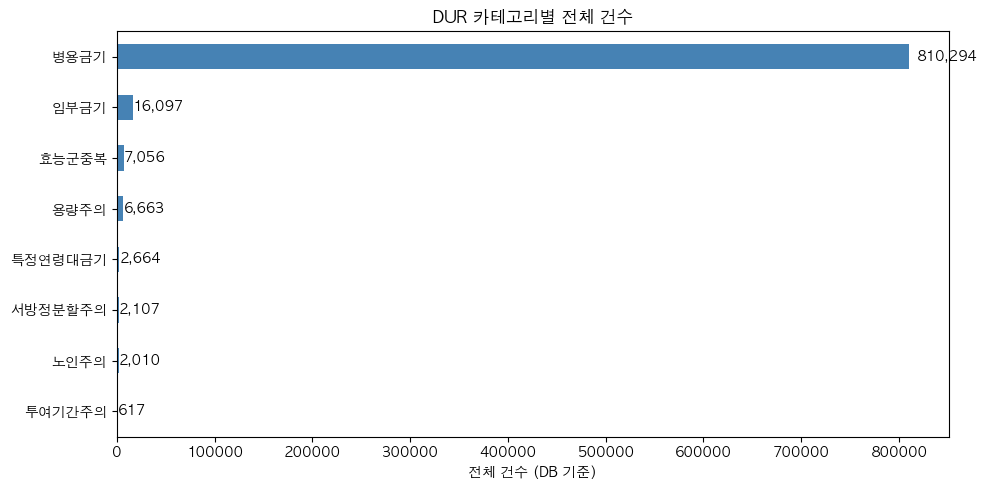

병용금기       810294
임부금기        16097
효능군중복        7056
용량주의         6663
특정연령대금기      2664
서방정분할주의      2107
노인주의         2010
투여기간주의        617


In [28]:
# 카테고리별 실제 건수 bar chart (totalCount 기준)
counts = pd.Series({label_map[k]: v for k, v in total_counts.items()}, name='전체 건수')

fig, ax = plt.subplots(figsize=(10, 5))
counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('전체 건수 (DB 기준)')
ax.set_title('DUR 카테고리별 전체 건수')
for i, v in enumerate(counts.sort_values()):
    ax.text(v * 1.01, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()
print(counts.sort_values(ascending=False).to_string())

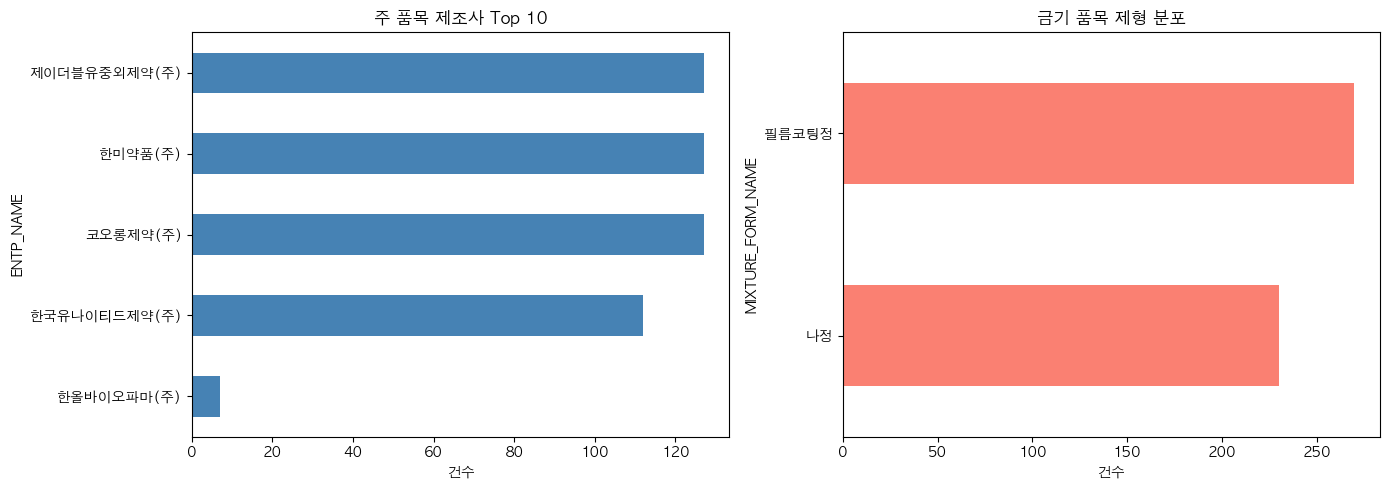

In [29]:
# 제조사별 분포 + 금기 품목 제형 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 주 품목 제조사 Top 10
if 'ENTP_NAME' in df_combo.columns:
    df_combo['ENTP_NAME'].value_counts().head(10).sort_values().plot(
        kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('주 품목 제조사 Top 10')
    axes[0].set_xlabel('건수')

# 금기 품목 제형 분포
mix_form = next((c for c in df_combo.columns if 'FORM' in c and 'NAME' in c and 'MIXTURE' in c), None)
if mix_form:
    df_combo[mix_form].value_counts().head(8).sort_values().plot(
        kind='barh', ax=axes[1], color='salmon')
    axes[1].set_title('금기 품목 제형 분포')
    axes[1].set_xlabel('건수')

plt.tight_layout()
plt.show()

In [30]:
# 병용금기 스키마 및 결측률
print(f'combo_item shape: {df_combo.shape}')
missing = (df_combo.isna() | (df_combo == '')).sum() / len(df_combo) * 100
print('\n결측률 (상위 10):')
print(missing.sort_values(ascending=False).head(10).to_string())

combo_item shape: (500, 43)

결측률 (상위 10):
MIX_INGR                100.0
REMARK                  100.0
MIXTURE_CHANGE_DATE       1.6
DUR_SEQ                   0.0
MIXTURE_ETC_OTC_NAME      0.0
MIXTURE_ITEM_SEQ          0.0
MIXTURE_ITEM_NAME         0.0
MIXTURE_ENTP_NAME         0.0
MIXTURE_FORM_CODE         0.0
MIXTURE_ETC_OTC_CODE      0.0


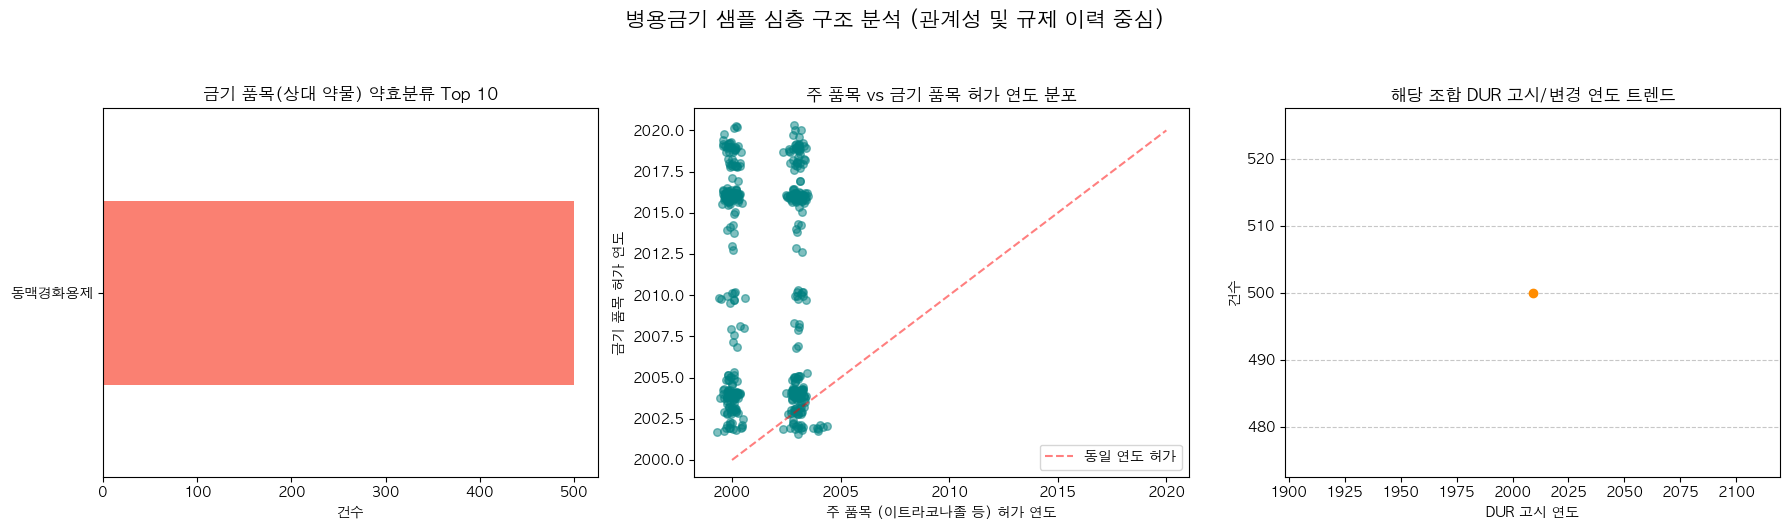

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 금기 품목(상대 약물) 약효 분류 Top 10
if 'MIXTURE_CLASS_NAME' in df_combo.columns:
    df_combo['MIXTURE_CLASS_NAME'].value_counts().head(10).sort_values().plot(
        kind='barh', ax=axes[0], color='salmon'
    )
    axes[0].set_title('금기 품목(상대 약물) 약효분류 Top 10')
    axes[0].set_xlabel('건수')
    axes[0].set_ylabel('')

# 2. 허가 연도 비교 (주 품목 vs 금기 품목) - 산점도(Scatter)
if 'ITEM_PERMIT_DATE' in df_combo.columns and 'MIXTURE_ITEM_PERMIT_DATE' in df_combo.columns:
    # 연도 추출
    item_yr = pd.to_datetime(df_combo['ITEM_PERMIT_DATE'], format='%Y%m%d', errors='coerce').dt.year
    mix_yr = pd.to_datetime(df_combo['MIXTURE_ITEM_PERMIT_DATE'], format='%Y%m%d', errors='coerce').dt.year
    
    # 겹치는 점이 많으므로 약간의 노이즈(Jitter)를 줘서 밀도 확인 (선택 사항)
    jitter_item = item_yr + np.random.normal(0, 0.2, size=len(item_yr))
    jitter_mix = mix_yr + np.random.normal(0, 0.2, size=len(mix_yr))
    
    axes[1].scatter(jitter_item, jitter_mix, alpha=0.5, color='teal', s=30)
    
    # y=x 기준선 (같은 해에 허가받은 약들)
    min_yr = min(item_yr.min(), mix_yr.min(skipna=True))
    max_yr = max(item_yr.max(), mix_yr.max(skipna=True))
    axes[1].plot([min_yr, max_yr], [min_yr, max_yr], 'r--', alpha=0.5, label='동일 연도 허가')
    
    axes[1].set_title('주 품목 vs 금기 품목 허가 연도 분포')
    axes[1].set_xlabel('주 품목 (이트라코나졸 등) 허가 연도')
    axes[1].set_ylabel('금기 품목 허가 연도')
    axes[1].legend()

# 3. DUR 규제 고시 연도 트렌드 (NOTIFICATION_DATE)
if 'NOTIFICATION_DATE' in df_combo.columns:
    notif_yr = pd.to_datetime(df_combo['NOTIFICATION_DATE'], format='%Y%m%d', errors='coerce').dt.year
    
    notif_yr.value_counts().sort_index().plot(
        kind='line', marker='o', ax=axes[2], color='darkorange', linewidth=2
    )
    axes[2].set_title('해당 조합 DUR 고시/변경 연도 트렌드')
    axes[2].set_xlabel('DUR 고시 연도')
    axes[2].set_ylabel('건수')
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('병용금기 샘플 심층 구조 분석 (관계성 및 규제 이력 중심)', y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

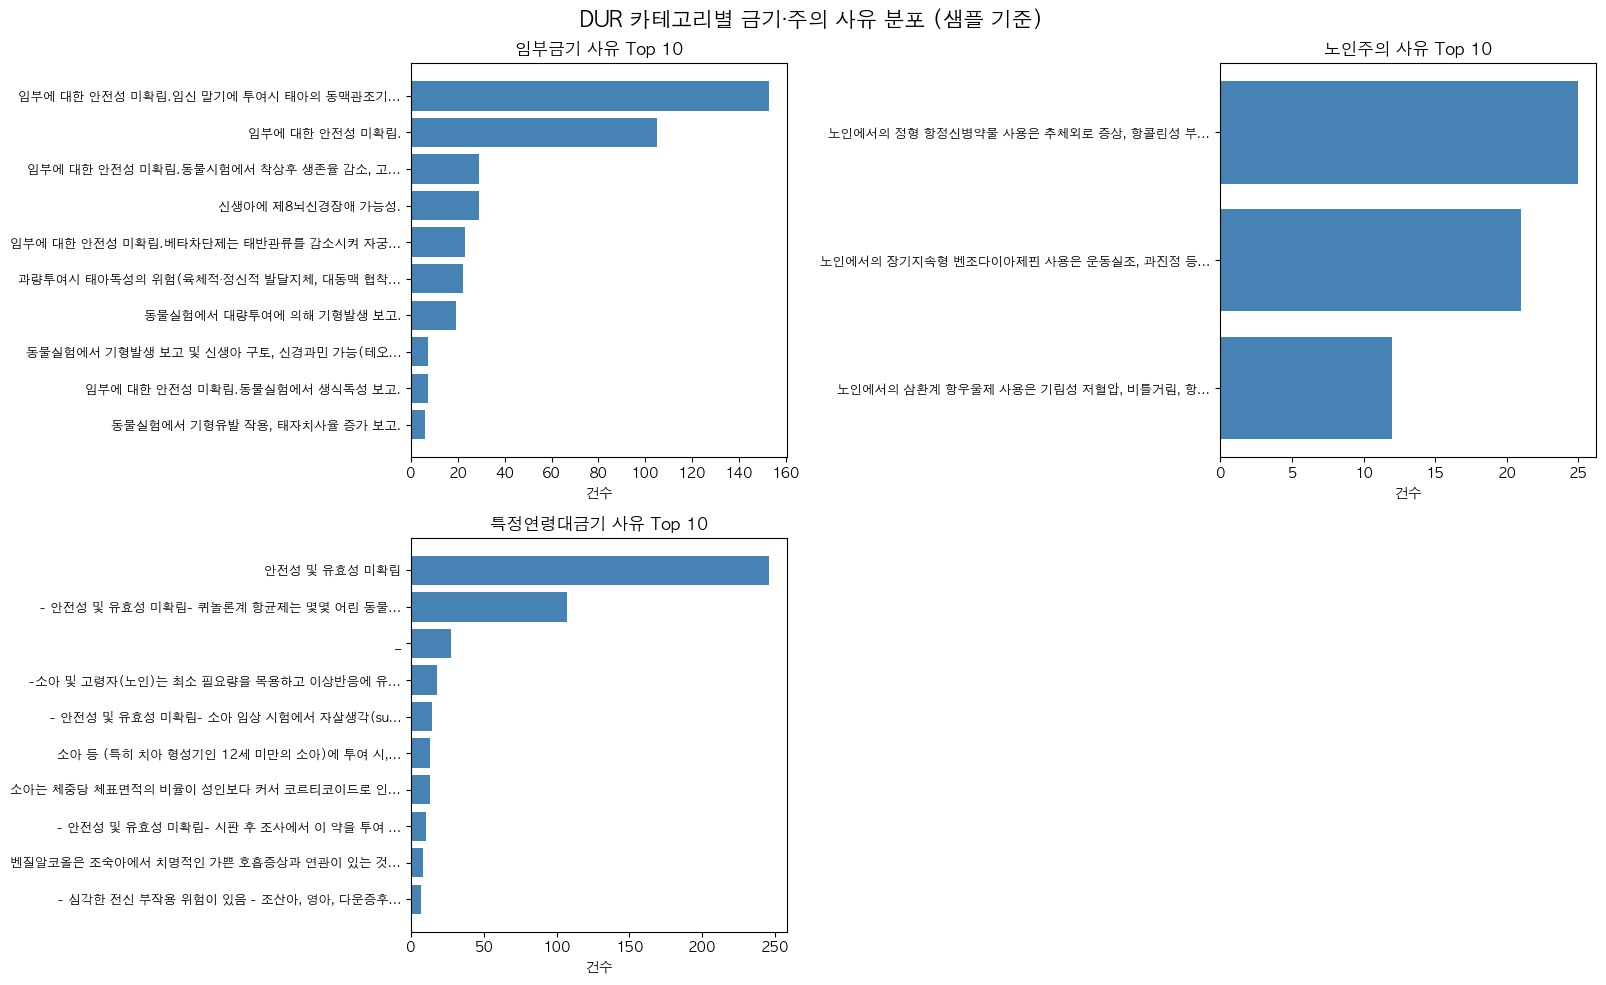

In [46]:
# 금기/주의 사유 분포 — 소규모 카테고리 기준
reason_targets = {
    'dur_preg_item':    '임부금기',
    'dur_senior_item':  '노인주의',
    'dur_age_item':     '특정연령대금기',
    'dur_period_item':  '투여기간주의',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

plotted = 0
for key, label in reason_targets.items():
    df_cat = item_dfs.get(key, pd.DataFrame())
    if df_cat.empty:
        continue
        
    reason_col = next((c for c in df_cat.columns if 'PROHBT' in c or 'ATENT' in c or '사유' in c or 'TABOO' in c), None)
    if reason_col is None:
        continue
        
    top = df_cat[reason_col].value_counts().head(10)
    if len(top) <= 1:
        continue
        
    # 텍스트가 35자를 넘어가면 자르고 '...' 붙이기
    short_labels = [
        str(idx)[:35] + '...' if len(str(idx)) > 35 else str(idx) 
        for idx in top.index
    ]
    
    axes_flat[plotted].barh(short_labels, top.values, color='steelblue')
    axes_flat[plotted].invert_yaxis() 
    axes_flat[plotted].set_title(f'{label} 사유 Top 10')
    axes_flat[plotted].set_xlabel('건수')
    axes_flat[plotted].tick_params(axis='y', labelsize=9) 
    
    plotted += 1

for i in range(plotted, 4):
    axes_flat[i].set_visible(False)

plt.suptitle('DUR 카테고리별 금기·주의 사유 분포 (샘플 기준)', fontsize=15)
plt.tight_layout()
plt.subplots_adjust(left=0.25)
plt.show()

In [47]:
# 병용금기 품목 저장
df_combo_out = df_combo.copy()
df_combo_out['_source'] = 'item'
out_path = INTERIM / 'dur_contraindication.parquet'
df_combo_out.to_parquet(out_path, index=False)
print(f'저장: {out_path}  ({len(df_combo_out):,}행)')

summary = {
    'sample_mode':        SAMPLE_MODE,
    'item_max_rows':      ITEM_MAX_ROWS,
    'total_counts':       {label_map[k]: v for k, v in total_counts.items()},
    'columns_combo_item': df_combo.columns.tolist(),
    'note': '성분 기반 API(DURPrdlstInfoService02)는 코드 체계 불일치로 EDA 범위 제외',
}
with open(INTERIM / 'dur_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print('저장 완료')
print(json.dumps(summary, ensure_ascii=False, indent=2))

저장: /Users/zzuhyeong2/Documents/Tobig's 25th/Conference/Pilliot_tobigs_conference_24_25/data/interim/dur_contraindication.parquet  (500행)
저장 완료
{
  "sample_mode": true,
  "item_max_rows": 500,
  "total_counts": {
    "병용금기": 810294,
    "임부금기": 16097,
    "용량주의": 6663,
    "투여기간주의": 617,
    "노인주의": 2010,
    "특정연령대금기": 2664,
    "효능군중복": 7056,
    "서방정분할주의": 2107
  },
  "columns_combo_item": [
    "DUR_SEQ",
    "TYPE_CODE",
    "TYPE_NAME",
    "MIX",
    "INGR_CODE",
    "INGR_KOR_NAME",
    "INGR_ENG_NAME",
    "MIX_INGR",
    "ITEM_SEQ",
    "ITEM_NAME",
    "ENTP_NAME",
    "CHART",
    "FORM_CODE",
    "ETC_OTC_CODE",
    "CLASS_CODE",
    "FORM_NAME",
    "ETC_OTC_NAME",
    "CLASS_NAME",
    "MAIN_INGR",
    "MIXTURE_DUR_SEQ",
    "MIXTURE_MIX",
    "MIXTURE_INGR_CODE",
    "MIXTURE_INGR_KOR_NAME",
    "MIXTURE_INGR_ENG_NAME",
    "MIXTURE_ITEM_SEQ",
    "MIXTURE_ITEM_NAME",
    "MIXTURE_ENTP_NAME",
    "MIXTURE_FORM_CODE",
    "MIXTURE_ETC_OTC_CODE",
    "MIXTURE_CLASS_CODE",